# Assignment 2 — Encoding & Transformation Impact

**Course:** Feature Engineering & MLOps  
**Assignment No.:** 2  
**Topic:** One-Hot Encoding (2.1) + Transformations & Model Comparison (2.2)

This notebook completes the assignment using the same PrepEdge `student_performance_raw.csv` dataset used in Assignment 1. It includes the required one-hot encoding, train-only preprocessing, skewness diagnosis, `log1p` transformation, four required model runs, R²/RMSE results, chart, conclusion, and the optional KNN bonus.

## Requirements Covered

- Reproducible 80/20 split.
- Train-only imputation and one-hot encoder fitting.
- One-hot encode `city`, `course`, `batch_type` with `handle_unknown='ignore'`.
- Report dimensionality before and after encoding.
- Diagnose right skew in `weekly_study_hours`.
- Apply and justify `np.log1p`.
- Keep all features identical except `weekly_study_hours` before/after.
- Compare Linear Regression and Decision Tree Regressor using test R² and RMSE.
- Use the same Decision Tree `random_state` and `max_depth`.
- Plot R² comparison.
- Explain linear-vs-tree behavior.
- Bonus: KNN before/after comparison.

## 1. Import Libraries and Set Reproducibility

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print("Libraries imported successfully. Random state:", RANDOM_STATE)

Libraries imported successfully. Random state: 42


## 2. Load the Same Dataset Used in Assignment 1

The repository path is `data/raw/student_performance_raw.csv`. A local fallback is included so the notebook also runs with the supplied CSV beside the notebook.

In [2]:
candidate_paths = [
    Path("data/raw/student_performance_raw.csv"),
    Path("../data/raw/student_performance_raw.csv"),
    Path("student_performance_raw.csv"),
    Path("/mnt/data/student_performance_raw.csv"),
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("student_performance_raw.csv was not found.")
df = pd.read_csv(DATA_PATH)
print("Loaded from:", DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())

Loaded from: ../data/raw/student_performance_raw.csv
Dataset shape: (600, 17)


,student_id,city,city_tier,course,batch_type,age,enrollment_date,attendance_pct,weekly_study_hours,income_bracket,prev_exam_score,mock_test_1,mock_test_2,mock_test_3,doubt_sessions_attended,feedback_text,final_score
0,1447,Patna,2,JEE Main,Weekday,18,2026-05-27,91.1000,0.8000,<5L,65.2000,68.1000,59.0000,72.2000,1,Need more practice sheets for weak topics,42.0000
1,1405,Patna,2,NEET,Weekday,16,2024-07-08,91.9000,2.4000,NaN,64.9000,82.0000,88.4000,100.0000,3,Would like more one-on-one mentoring,62.0000
2,1510,Mumbai,1,JEE Main,Weekday,18,2025-03-17,67.1000,6.7000,5-10L,90.1000,86.5000,91.1000,76.4000,5,"Great teaching pace, doubts cleared quickly",56.4000
3,1456,Delhi,1,NEET,Weekday,18,2025-06-16,70.7000,2.0000,10-20L,29.7000,19.4000,24.9000,NaN,3,Need more practice sheets for weak topics,31.7000
4,1202,Patna,2,JEE Advanced,Weekday,17,2026-04-16,69.3000,6.5000,>20L,70.0000,63.8000,74.5000,69.1000,4,Need more practice sheets for weak topics,44.5000


In [3]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

Columns:
['student_id', 'city', 'city_tier', 'course', 'batch_type', 'age', 'enrollment_date', 'attendance_pct', 'weekly_study_hours', 'income_bracket', 'prev_exam_score', 'mock_test_1', 'mock_test_2', 'mock_test_3', 'doubt_sessions_attended', 'feedback_text', 'final_score']

Data types:


,dtype
student_id,int64
city,str
city_tier,int64
course,str
batch_type,str
age,int64
enrollment_date,str
attendance_pct,float64
weekly_study_hours,float64
income_bracket,str



Missing values:


,missing_count
student_id,0
city,0
city_tier,0
course,0
batch_type,0
age,0
enrollment_date,0
attendance_pct,0
weekly_study_hours,36
income_bracket,30


## 3. Part 2.1 — Nominal Categorical Columns

The required nominal categorical columns are `city`, `course`, and `batch_type`. They are nominal because their categories have no meaningful natural order, so one-hot encoding is appropriate.

In [4]:
categorical_columns = ["city", "course", "batch_type"]
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique categories")
    print(sorted(df[col].dropna().astype(str).unique().tolist()))
    print()

city: 8 unique categories
['Bengaluru', 'Delhi', 'Hyderabad', 'Kota', 'Lucknow', 'Mumbai', 'Patna', 'Pune']

course: 4 unique categories
['Foundation', 'JEE Advanced', 'JEE Main', 'NEET']

batch_type: 3 unique categories
['Crash Course', 'Weekday', 'Weekend']



## 4. Train/Test Split — 80/20

The split is made before fitting learned preprocessing so no test-set information leaks into the training process.

In [5]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=RANDOM_STATE)
train_df = train_df.copy(); test_df = test_df.copy()
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
assert len(train_df) == 480 and len(test_df) == 120

Training shape: (480, 17)
Test shape: (120, 17)


## 5. Missing-Value Imputation — Training Data Only

The assignment notes missing values in `weekly_study_hours` and `prev_exam_score`. Median imputation is fitted on training data only and then applied to both splits.

In [6]:
numeric_impute_columns = ["weekly_study_hours", "prev_exam_score"]
numeric_imputer = SimpleImputer(strategy="median")
train_df[numeric_impute_columns] = numeric_imputer.fit_transform(train_df[numeric_impute_columns])
test_df[numeric_impute_columns] = numeric_imputer.transform(test_df[numeric_impute_columns])
imputation_values = pd.Series(numeric_imputer.statistics_, index=numeric_impute_columns, name="training_median_used")
display(imputation_values.to_frame())
assert train_df[numeric_impute_columns].isna().sum().sum() == 0
assert test_df[numeric_impute_columns].isna().sum().sum() == 0
print("Imputation verification passed.")

,training_median_used
weekly_study_hours,5.0000
prev_exam_score,66.1000


Imputation verification passed.


## 6. One-Hot Encoding — Fit on Training Categories Only

`OneHotEncoder(handle_unknown='ignore')` is fitted on the training categorical columns and used to transform both splits. If a category occurs only in the test set, it will not cause an error.

In [7]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(train_df[categorical_columns])
X_test_cat = encoder.transform(test_df[categorical_columns])
encoded_feature_names = encoder.get_feature_names_out(categorical_columns)
X_train_cat = pd.DataFrame(X_train_cat, columns=encoded_feature_names, index=train_df.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=encoded_feature_names, index=test_df.index)
print("One-hot columns created:", len(encoded_feature_names))
display(pd.DataFrame({"encoded_column": encoded_feature_names}))
print("\nTraining categories:")
for col,cats in zip(categorical_columns, encoder.categories_): print(col, list(cats))

One-hot columns created: 15


,encoded_column
0,city_Bengaluru
1,city_Delhi
2,city_Hyderabad
3,city_Kota
4,city_Lucknow
5,city_Mumbai
6,city_Patna
7,city_Pune
8,course_Foundation
9,course_JEE Advanced



Training categories:
city ['Bengaluru', 'Delhi', 'Hyderabad', 'Kota', 'Lucknow', 'Mumbai', 'Patna', 'Pune']
course ['Foundation', 'JEE Advanced', 'JEE Main', 'NEET']
batch_type ['Crash Course', 'Weekday', 'Weekend']


In [8]:
unseen_categories = {}
for col, train_categories in zip(categorical_columns, encoder.categories_):
    unseen_categories[col] = sorted(set(test_df[col].dropna().astype(str)) - set(train_categories.astype(str)))
unseen_df = pd.DataFrame({"column":list(unseen_categories), "test_only_categories":[", ".join(v) if v else "None" for v in unseen_categories.values()]})
display(unseen_df)
print("handle_unknown='ignore' prevents errors for unseen test categories.")

,column,test_only_categories
0,city,None
1,course,None
2,batch_type,None


handle_unknown='ignore' prevents errors for unseen test categories.


## 7. Dimensionality Before and After One-Hot Encoding

In [9]:
numeric_predictors = ["weekly_study_hours", "attendance_pct", "prev_exam_score", "doubt_sessions_attended"]
target_column = "final_score"
raw_column_count = df.shape[1]
selected_before = len(numeric_predictors) + len(categorical_columns)
selected_after = len(numeric_predictors) + len(encoded_feature_names)
dimension_table = pd.DataFrame({"representation":["Raw complete dataset","Selected modeling features before encoding","Selected modeling features after one-hot encoding"],"number_of_columns":[raw_column_count,selected_before,selected_after]})
display(dimension_table)
print(f"Selected modeling feature space increased from {selected_before} to {selected_after} columns.")

,representation,number_of_columns
0,Raw complete dataset,17
1,Selected modeling features before encoding,7
2,Selected modeling features after one-hot encoding,19


Selected modeling feature space increased from 7 to 19 columns.


# Part 2.2 — Transformations & Model Comparison

## 8. Diagnose Skewness

In [10]:
raw_skew = df["weekly_study_hours"].skew()
train_skew = train_df["weekly_study_hours"].skew()
skewness_table = pd.DataFrame({"dataset_version":["Original data","Training data after median imputation"],"weekly_study_hours_skewness":[raw_skew,train_skew]})
display(skewness_table)
print(f"Original skewness = {raw_skew:.4f}; positive skew confirms a right-skewed feature.")
assert raw_skew > 0.5

,dataset_version,weekly_study_hours_skewness
0,Original data,1.5132
1,Training data after median imputation,1.5957


Original skewness = 1.5132; positive skew confirms a right-skewed feature.


## 9. Choose and Apply a Transformation — `np.log1p`

`weekly_study_hours` is non-negative and strongly right-skewed, so `log1p` is appropriate. It compresses large values while preserving their order and is defined at zero.

In [11]:
assert train_df["weekly_study_hours"].min() >= 0
train_weekly_before = train_df["weekly_study_hours"].copy()
test_weekly_before = test_df["weekly_study_hours"].copy()
train_weekly_after = np.log1p(train_weekly_before)
test_weekly_after = np.log1p(test_weekly_before)
transformation_table = pd.DataFrame({"statistic":["mean","median","std","skewness","minimum","maximum"],"before":[train_weekly_before.mean(),train_weekly_before.median(),train_weekly_before.std(),train_weekly_before.skew(),train_weekly_before.min(),train_weekly_before.max()],"after_log1p":[train_weekly_after.mean(),train_weekly_after.median(),train_weekly_after.std(),train_weekly_after.skew(),train_weekly_after.min(),train_weekly_after.max()]})
display(transformation_table)

,statistic,before,after_log1p
0,mean,6.0088,1.7831
1,median,5.0000,1.7918
2,std,4.2418,0.5774
3,skewness,1.5957,-0.0392
4,minimum,0.2000,0.1823
5,maximum,31.4000,3.4782


## 10. Build Identical Before/After Feature Matrices

Only `weekly_study_hours` changes. The one-hot columns and all other numeric predictors remain identical.

In [12]:
def build_feature_matrix(frame, weekly_values, encoded_part):
    numeric_part = frame[["attendance_pct", "prev_exam_score", "doubt_sessions_attended"]].copy()
    numeric_part["weekly_study_hours"] = weekly_values
    numeric_part = numeric_part[["weekly_study_hours", "attendance_pct", "prev_exam_score", "doubt_sessions_attended"]]
    return pd.concat([numeric_part, encoded_part], axis=1)

X_train_before = build_feature_matrix(train_df, train_weekly_before, X_train_cat)
X_test_before = build_feature_matrix(test_df, test_weekly_before, X_test_cat)
X_train_after = build_feature_matrix(train_df, train_weekly_after, X_train_cat)
X_test_after = build_feature_matrix(test_df, test_weekly_after, X_test_cat)
y_train = train_df[target_column].copy(); y_test = test_df[target_column].copy()
print("Before shapes:", X_train_before.shape, X_test_before.shape)
print("After shapes :", X_train_after.shape, X_test_after.shape)
common_other_columns = [c for c in X_train_before.columns if c != "weekly_study_hours"]
assert X_train_before[common_other_columns].equals(X_train_after[common_other_columns])
assert X_test_before[common_other_columns].equals(X_test_after[common_other_columns])
print("Feature-isolation check passed.")

Before shapes: (480, 19) (120, 19)
After shapes : (480, 19) (120, 19)
Feature-isolation check passed.


## 11. Train the Four Required Models

Decision Tree uses the same fixed `random_state` and `max_depth` in both runs. The same train/test rows are used for every model.

In [13]:
tree_max_depth = 5
models = {"Linear Regression":LinearRegression(),"Decision Tree Regressor":DecisionTreeRegressor(max_depth=tree_max_depth, random_state=RANDOM_STATE)}
results=[]
for model_name, model in models.items():
    for version, Xtr, Xte in [("Before",X_train_before,X_test_before),("After",X_train_after,X_test_after)]:
        model.fit(Xtr,y_train)
        pred=model.predict(Xte)
        results.append({"Model":model_name,"Feature Version":version,"R2":r2_score(y_test,pred),"RMSE":np.sqrt(mean_squared_error(y_test,pred))})
results_df=pd.DataFrame(results)
display(results_df.round(4))

,Model,Feature Version,R2,RMSE
0,Linear Regression,Before,0.5930,6.3915
1,Linear Regression,After,0.5734,6.5435
2,Decision Tree Regressor,Before,0.4461,7.4564
3,Decision Tree Regressor,After,0.4461,7.4564


## 12. Required Results Table — Test R² and RMSE

In [14]:
display(results_df.round(4))
print("Higher R² is better; lower RMSE is better.")

,Model,Feature Version,R2,RMSE
0,Linear Regression,Before,0.5930,6.3915
1,Linear Regression,After,0.5734,6.5435
2,Decision Tree Regressor,Before,0.4461,7.4564
3,Decision Tree Regressor,After,0.4461,7.4564


Higher R² is better; lower RMSE is better.


## 13. R² Comparison Bar Chart

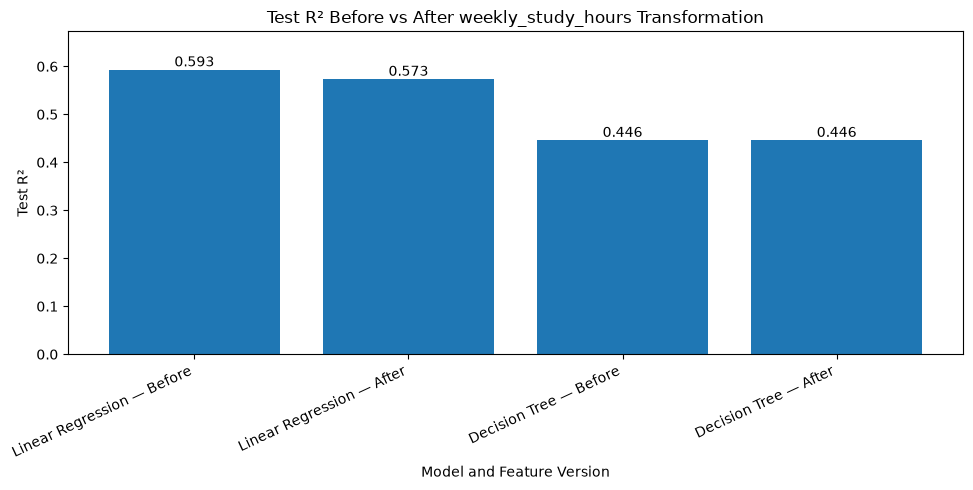

In [15]:
labels=results_df["Model"].str.replace(" Regressor","",regex=False)+" — "+results_df["Feature Version"]
plt.figure(figsize=(10,5))
bars=plt.bar(labels,results_df["R2"])
plt.ylabel("Test R²"); plt.xlabel("Model and Feature Version")
plt.title("Test R² Before vs After weekly_study_hours Transformation")
plt.xticks(rotation=25,ha="right")
plt.ylim(min(0,results_df["R2"].min()-0.05),min(1.0,results_df["R2"].max()+0.08))
for bar,value in zip(bars,results_df["R2"]): plt.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f"{value:.3f}",ha="center",va="bottom")
plt.tight_layout(); plt.show()

## 14. Quantify Before/After Changes

In [16]:
comparison=results_df.pivot(index="Model",columns="Feature Version",values=["R2","RMSE"])
comparison["R2","Delta (After-Before)"]=comparison["R2","After"]-comparison["R2","Before"]
comparison["RMSE","Delta (After-Before)"]=comparison["RMSE","After"]-comparison["RMSE","Before"]
display(comparison.round(4))

R2          RMSE                          R2  \
Feature Version          After Before  After Before Delta (After-Before)   
Model                                                                      
Decision Tree Regressor 0.4461 0.4461 7.4564 7.4564               0.0000   
Linear Regression       0.5734 0.5930 6.5435 6.3915              -0.0196   

                                        RMSE  
Feature Version         Delta (After-Before)  
Model                                         
Decision Tree Regressor               0.0000  
Linear Regression                     0.1520

## 15. Decision Tree Experimental-Control Check

In [17]:
tree_before=DecisionTreeRegressor(max_depth=tree_max_depth,random_state=RANDOM_STATE)
tree_after=DecisionTreeRegressor(max_depth=tree_max_depth,random_state=RANDOM_STATE)
assert tree_before.get_params()["max_depth"]==tree_after.get_params()["max_depth"]
assert tree_before.get_params()["random_state"]==tree_after.get_params()["random_state"]
print("Decision Tree control check passed.")
print("max_depth:",tree_max_depth,"random_state:",RANDOM_STATE)

Decision Tree control check passed.
max_depth: 5 random_state: 42


# Bonus (+10%) — K-Nearest Neighbors Regressor

KNN is distance-based. Both versions use the same `StandardScaler` and `n_neighbors=10`; only the weekly-study-hours representation changes.

In [18]:
knn_before=Pipeline([("scaler",StandardScaler()),("knn",KNeighborsRegressor(n_neighbors=10))])
knn_after=Pipeline([("scaler",StandardScaler()),("knn",KNeighborsRegressor(n_neighbors=10))])
knn_results=[]
for version,Xtr,Xte,pipeline in [("Before",X_train_before,X_test_before,knn_before),("After",X_train_after,X_test_after,knn_after)]:
    pipeline.fit(Xtr,y_train); pred=pipeline.predict(Xte)
    knn_results.append({"Model":"KNN Regressor","Feature Version":version,"R2":r2_score(y_test,pred),"RMSE":np.sqrt(mean_squared_error(y_test,pred))})
knn_results_df=pd.DataFrame(knn_results)
display(knn_results_df.round(4))

,Model,Feature Version,R2,RMSE
0,KNN Regressor,Before,0.1404,9.2886
1,KNN Regressor,After,0.1383,9.3000


## 16. Bonus Interpretation

KNN computes distances between rows. A skewed feature with extreme values can influence those distances strongly. A log transformation compresses the long tail, potentially changing nearest-neighbor relationships. This is why KNN can respond more directly to a transformation than a threshold-based tree.

In [19]:
knn_delta_r2=knn_results_df.loc[knn_results_df["Feature Version"]=="After","R2"].iloc[0]-knn_results_df.loc[knn_results_df["Feature Version"]=="Before","R2"].iloc[0]
knn_delta_rmse=knn_results_df.loc[knn_results_df["Feature Version"]=="After","RMSE"].iloc[0]-knn_results_df.loc[knn_results_df["Feature Version"]=="Before","RMSE"].iloc[0]
print(f"KNN ΔR² (After-Before): {knn_delta_r2:.4f}")
print(f"KNN ΔRMSE (After-Before): {knn_delta_rmse:.4f}")

KNN ΔR² (After-Before): -0.0021
KNN ΔRMSE (After-Before): 0.0114


# 17. Written Conclusion

The assignment asks why Linear Regression changes after transformation while the Decision Tree changes much less, referring to the internal mechanics of each model.

In [20]:
lin_b=results_df.query("`Model`=='Linear Regression' and `Feature Version`=='Before'").iloc[0]
lin_a=results_df.query("`Model`=='Linear Regression' and `Feature Version`=='After'").iloc[0]
tree_b=results_df.query("`Model`=='Decision Tree Regressor' and `Feature Version`=='Before'").iloc[0]
tree_a=results_df.query("`Model`=='Decision Tree Regressor' and `Feature Version`=='After'").iloc[0]
print(f"Linear Regression: R² before={lin_b.R2:.4f}, after={lin_a.R2:.4f}, ΔR²={lin_a.R2-lin_b.R2:.4f}")
print(f"Decision Tree: R² before={tree_b.R2:.4f}, after={tree_a.R2:.4f}, ΔR²={tree_a.R2-tree_b.R2:.4f}")

Linear Regression: R² before=0.5930, after=0.5734, ΔR²=-0.0196
Decision Tree: R² before=0.4461, after=0.4461, ΔR²=0.0000


### Conclusion

The results show why a monotonic transformation can affect linear and tree-based models differently. Linear Regression represents the relationship through coefficients multiplying the raw feature values, so a strongly right-skewed predictor can make a straight-line relationship less suitable; the log transformation compresses the long tail and can make the feature's relationship with the target easier for the linear model to represent. A Decision Tree Regressor instead searches for threshold splits, so a monotonic transformation preserves the ordering of observations: a split at one value in the original scale corresponds to a split at another value in the transformed scale. Therefore, with the same tree depth and random state, its performance should usually change much less than the linear model. The exact R² and RMSE changes shown in the results table are the empirical results for this dataset.

## 18. Final Verification Checklist

In [21]:
required_columns={"city","course","batch_type","weekly_study_hours","attendance_pct","prev_exam_score","doubt_sessions_attended","final_score"}
assert required_columns.issubset(df.columns)
assert len(train_df)==480 and len(test_df)==120
assert train_df[numeric_impute_columns].isna().sum().sum()==0 and test_df[numeric_impute_columns].isna().sum().sum()==0
assert encoder.handle_unknown=="ignore"
assert X_train_cat.shape[1]==X_test_cat.shape[1]
assert X_train_before.shape==X_train_after.shape and X_test_before.shape==X_test_after.shape
assert X_train_before[common_other_columns].equals(X_train_after[common_other_columns])
assert X_test_before[common_other_columns].equals(X_test_after[common_other_columns])
assert len(results_df)==4 and set(results_df["Model"])=={"Linear Regression","Decision Tree Regressor"}
assert set(results_df["Feature Version"])=={"Before","After"}
assert results_df[["R2","RMSE"]].notna().all().all()
assert tree_max_depth==5 and RANDOM_STATE==42
assert len(knn_results_df)==2 and knn_results_df[["R2","RMSE"]].notna().all().all()
print("============================================================")
print("ALL ASSIGNMENT 2 CORE + BONUS VALIDATION CHECKS PASSED.")
print("============================================================")

ALL ASSIGNMENT 2 CORE + BONUS VALIDATION CHECKS PASSED.


## 19. Submission Structure

The assignment requires the notebook to be named exactly:

```text
Assignments/Assignment2_Encoding_Transformation.ipynb
```

Suggested commands:

```bash
git add Assignments/Assignment2_Encoding_Transformation.ipynb
git commit -m "Assignment 2: Encoding and Transformation impact"
git push
```

Run the notebook top-to-bottom before committing so the outputs and chart remain visible.